In [1]:
import matplotlib.pyplot as plt
import numpy as np

from irsa.io import load_spectra
from irsa.spectra import SpectraCollection
import mlgrad.smooth as smooth
import mlgrad.funcs as funcs
import mlgrad.inventory as inventory

from sklearn.decomposition import PCA
import ipywidgets

# %matplotlib widget

In [2]:
dd = SpectraCollection()
dd.load("/home/intellimath/work/spectra/13", "origin")
keys = list(dd.keys())
x = dd[keys[0]].x
ys = dd[keys[0]].y
y = ys[0]

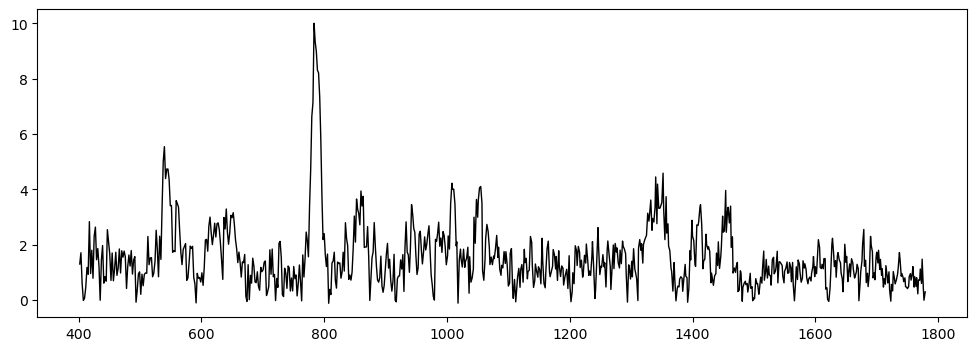

In [3]:
bl, _ = smooth.whittaker_smooth_weight_func2(
        y,func=funcs.Step(0.00, eps=0.001),
        # func2=funcs.Step(0.00, eps=0.001),
        # func2_e=inventory.relative_abs_max,
        tau2=1.0e6, d=4)
y_bl = y - bl
y_bl /= y_bl.max()
y_bl *= 10
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='k', linewidth=1.0)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


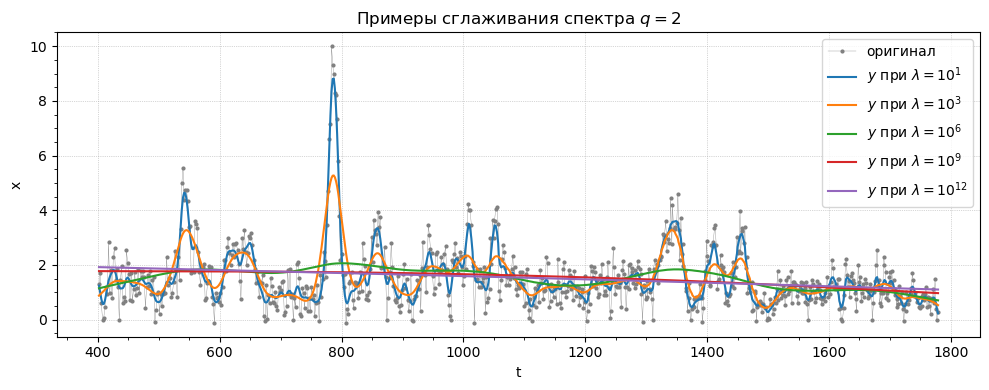

In [4]:
js = [1, 3, 6, 9, 12]
zs = [smooth.whittaker_smooth(y_bl, tau2=10**j, d=2) for j in js]

plt.figure(figsize=(10,4))
plt.title(r"Примеры сглаживания спектра $q=2$")
plt.plot(x, y_bl, color='gray', linewidth=0.25, marker='o', ms=2.0, label="оригинал")
for i,z in enumerate(zs):
    plt.plot(x, z, linewidth=1.5, label=r"$y$ при $\lambda=$"+ r"$10^{%s}$" % js[i])
plt.xlabel("t")
plt.ylabel("x")
plt.minorticks_on()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
plt.legend()
plt.savefig("fig/smooth1.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


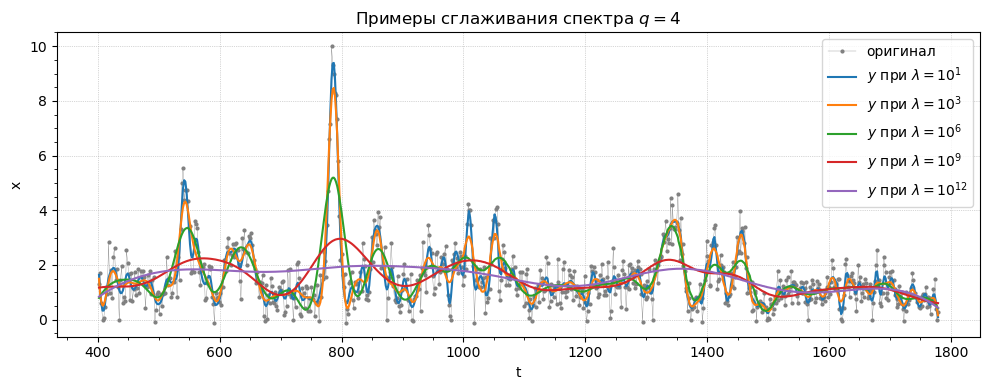

In [5]:
js = [1, 3, 6, 9, 12]
softabs_func = funcs.SoftAbs(0.00001)
abs_func = funcs.Abs()
zs2 = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=10**j, 
                                            # func=softabs_func.derivative_div_array, 
                                            # func2=softabs_func.derivative_div_array, 
                                            d=4)[0] \
     for j in js]

plt.figure(figsize=(10,4))
plt.title(r"Примеры сглаживания спектра $q=4$")
plt.plot(x, y_bl, color='gray', linewidth=0.25, marker='o', ms=2.0, label="оригинал")
for i,z in enumerate(zs2):
    plt.plot(x, z, linewidth=1.5, label=r"$y$ при $\lambda=$" + r"$10^{%s}$" % js[i])
plt.xlabel("t")
plt.ylabel("x")
plt.minorticks_on()
plt.tight_layout()
# plt.grid(linestyle=':')
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/smooth2.eps")
plt.show()

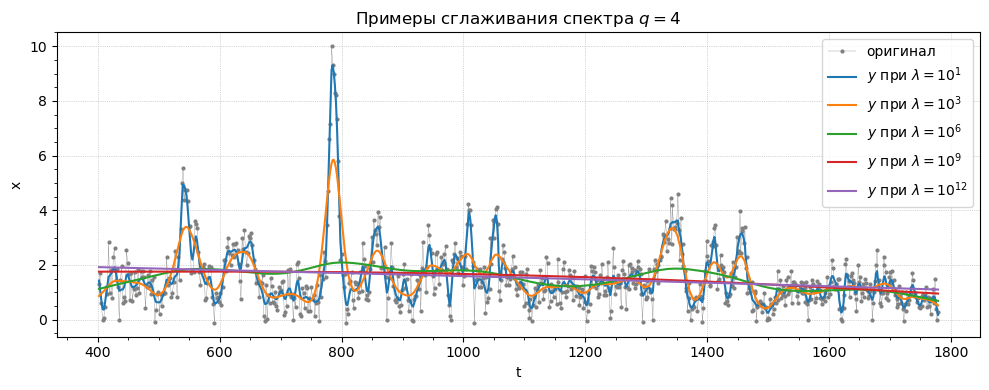

In [6]:
js = [1, 3, 6, 9, 12]
softabs_func = funcs.SoftAbs(0.25)
sq_func = funcs.Square()
# func_lc = funcs.LinearComp(sq_func, softabs_func, 0.1, 1.0)
abs_func = funcs.Abs()
zs3 = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=0.1*10**j, 
                                            # func=softabs_func.derivative_div_array, 
                                            func2=softabs_func.derivative_div_array, 
                                            d=2)[0] \
     for j in js]

plt.figure(figsize=(10,4))
plt.title(r"Примеры сглаживания спектра $q=4$")
plt.plot(x, y_bl, color='gray', linewidth=0.25, marker='o', ms=2.0, label="оригинал")
for i,z in enumerate(zs3):
    plt.plot(x, z, linewidth=1.5, label=r"$y$ при $\lambda=$" + r"$10^{%s}$" % js[i])
plt.xlabel("t")
plt.ylabel("x")
plt.minorticks_on()
plt.tight_layout()
# plt.grid(linestyle=':')
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


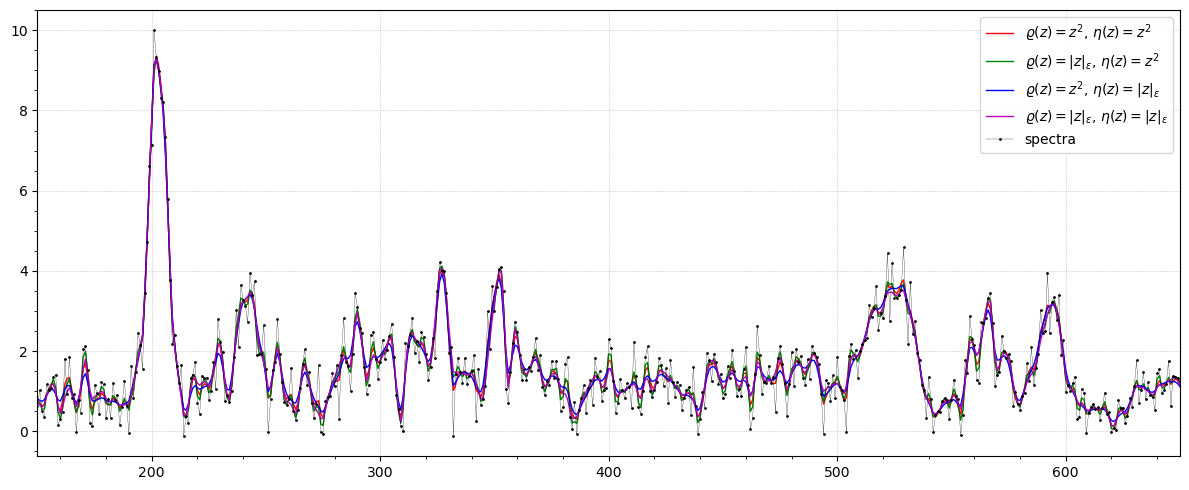

In [7]:
z4, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=2)
z3, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=sq_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=2)
z2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=sq_func.derivative_div_array, 
                                          d=2)
z = smooth.whittaker_smooth(y_bl, tau2=1.0, d=2)


plt.figure(figsize=(12,5))
plt.plot(z, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
plt.plot(z2, lw=1.0, color='g', 
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=z^2$")
plt.plot(z3, lw=1.0, color='b',
         label=r"$\varrho(z)=z^2$, $\eta(z)=|z|_\epsilon$")
plt.plot(z4, lw=1.0, color='m',
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
plt.plot(y_bl, color='k', lw=0.2, marker='o', ms=1, label='spectra')
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(150,650)
plt.savefig("fig/smooth3.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


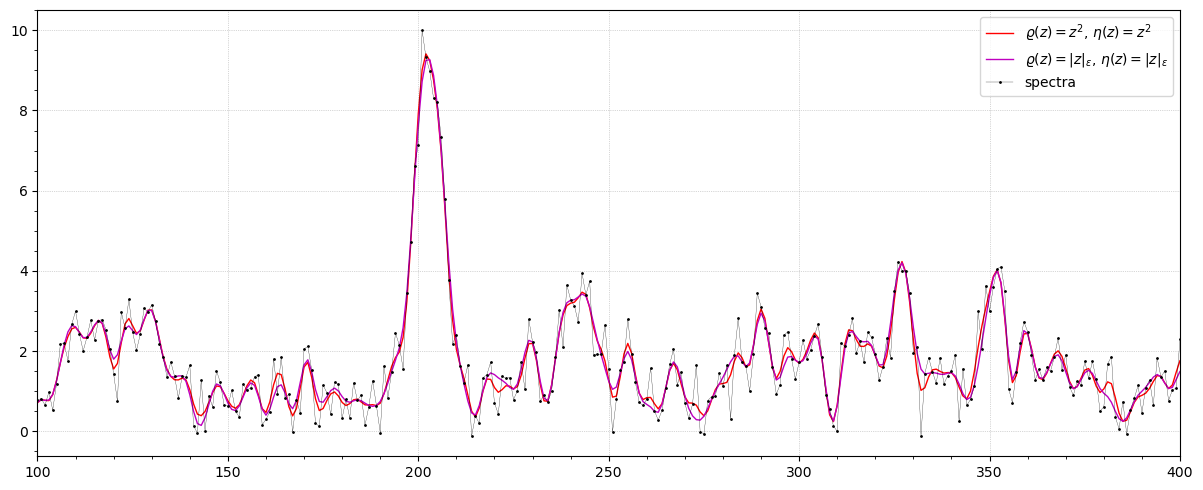

In [8]:
z4, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=4)
z3, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=sq_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=4)
z2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=sq_func.derivative_div_array, 
                                          d=4)
z = smooth.whittaker_smooth(y_bl, tau2=1.0, d=4)


plt.figure(figsize=(12,5))
plt.plot(z, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(z2, lw=1.0, color='g', 
#          label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=z^2$")
# plt.plot(z3, lw=1.0, color='b',
#          label=r"$\varrho(z)=z^2$, $\eta(z)=|z|_\epsilon$")
plt.plot(z4, lw=1.0, color='m',
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
plt.plot(y_bl, color='k', lw=0.2, marker='o', ms=1, label='spectra')
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(100,400)
plt.savefig("fig/smooth4.eps")
plt.show()

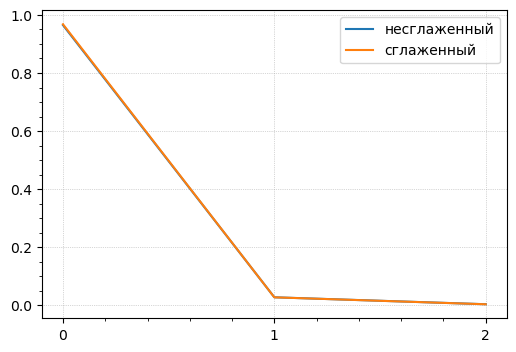

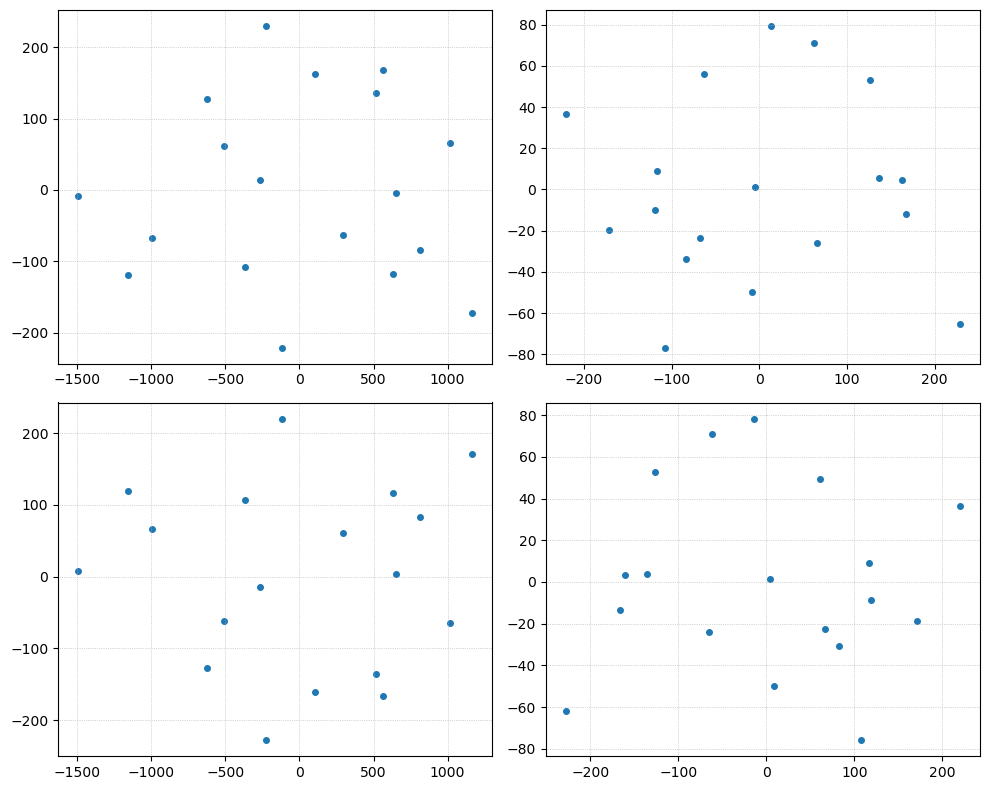

In [9]:
zs = [smooth.whittaker_smooth(y, tau2=1.0, d=2) for y in ys]
pca_ys = PCA().fit(ys)
us_ys = pca_ys.transform(ys)
pca_zs = PCA().fit(zs)
us_zs = pca_zs.transform(zs)

plt.figure(figsize=(6,4))
plt.plot(pca_ys.explained_variance_ratio_[:3], label="несглаженный")
plt.plot(pca_zs.explained_variance_ratio_[:3], label="сглаженный")
plt.grid(ls=':', lw=0.5)
plt.minorticks_on()
plt.xticks([0,1,2])
plt.legend()
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.scatter(us_ys[:,0], us_ys[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,2)
plt.scatter(us_ys[:,1], us_ys[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,3)
plt.scatter(us_zs[:,0], us_zs[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,4)
plt.scatter(us_zs[:,1], us_zs[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.tight_layout()
# plt.legend()
plt.show()

In [17]:
#tau2_slider = ipywidgets.FloatSlider(value=1, min=0, max=1.0e8, step=10)
alpha_slider = ipywidgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.001, readout_format=".3f")
alpha_slider.layout.width="50%"

@ipywidgets.interact(alpha=alpha_slider, continuous_update=False)
def plot_baseline(alpha):
    if alpha == 0:
        alpha = 1.0e-6
    elif alpha == 1:
        alpha = 1 - 1.0e-6
    y1 = y
    # y1 = smooth.whittaker_smooth(y, tau2=10.0, d=2)
    bl1, _ = smooth.whittaker_smooth_weight_func2(
            y1, 
            # func=funcs.Quantile(alpha),
            # func=funcs.Step(0.0, eps=alpha),
            func=funcs.Weibul(alpha),
            # func=funcs.Exp(-0.5),
            # func2=funcs.Step(0.0, 0.001),
            # func2_e=inventory.relative_abs_max,
            tau2=1.0, d=2)
    # bl2, _ = smooth.whittaker_smooth_weight_func2(
    #         y1, func=smooth.func_aspls,
    #         # func2=funcs.StepRight(0.0, eps=0.001),
    #         func2_e=inventory.relative_abs_max,
    #         tau2=1.0e5, d=2)
    
    plt.figure(figsize=(10,5))
    plt.title(r"Примеры поиска базовой линии спектра")
    plt.plot(x, y1, color='gray', linewidth=0.5,  ms=2.0, label="оригинал")
    plt.plot(x, bl1, linewidth=1.5, label=r"step")
    # plt.plot(x, bl2, linewidth=1.5, label=r"aspls")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.minorticks_on()
    plt.tight_layout()
    plt.grid(ls=':', lw=0.5)
    plt.legend()
    # plt.savefig("fig/smooth_.eps")
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='alpha', layout=Layout(width='50%'), max=1.0, readout…

In [11]:
0.5*1/36

0.013888888888888888